In [1]:
5*59/75

3.933333333333333


# Regresión con SVM



Como se mencionó anteriormente, el algoritmo SVM es versátil: no solo admite clasificación lineal y no lineal, sino también regresión lineal y no lineal. 

Para usar SVM para regresión en lugar de clasificación, el truco consiste en invertir el objetivo: en lugar de intentar ajustar la calle más amplia posible entre dos clases mientras se limitan las violaciones del margen, la **Regresión SVM** intenta ajustar tantas instancias como sea posible *dentro* de la calle mientras se limitan las violaciones del margen (es decir, instancias fuera de la calle). 

El ancho de la calle está controlado por un hiperparámetro, $\epsilon$ (épsilon).



La Figura 5-10 muestra dos modelos de Regresión SVM lineal entrenados con algunos datos lineales aleatorios, uno con un margen grande ($\epsilon = 1.5$) y el otro con un margen pequeño ($\epsilon = 0.5$).



**Figura 5-10. Regresión SVM**



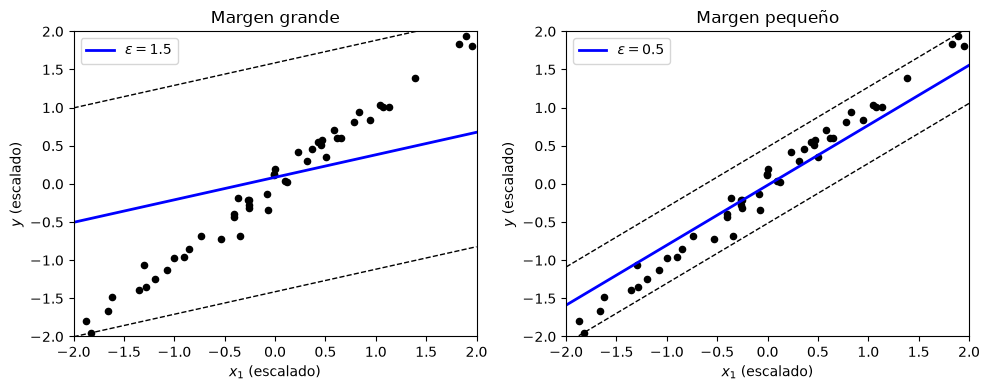

In [ ]:
# Código para generar la Figura 5-10
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR

# Generar datos lineales aleatorios
np.random.seed(42)
X = np.random.randn(50, 1) * 2
y = 2 * X.ravel() + 1 + np.random.randn(50) * 0.5

# Escalar los datos
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Entrenar modelos con diferentes épsilon (cambiado dual=True)
svm_reg1 = LinearSVR(epsilon=1.5, random_state=42, dual=True)
svm_reg2 = LinearSVR(epsilon=0.5, random_state=42, dual=True)
svm_reg1.fit(X_scaled, y_scaled)
svm_reg2.fit(X_scaled, y_scaled)


# Función para graficar
def plot_svm_regression(svm_reg, X, y, axes, label=None):
    x0s = np.linspace(axes[0], axes[1], 100).reshape(-1, 1)
    y_pred = svm_reg.predict(x0s)
    plt.plot(x0s, y_pred, "b-", linewidth=2, label=label)
    plt.plot(x0s, y_pred - svm_reg.epsilon, "k--", linewidth=1)
    plt.plot(x0s, y_pred + svm_reg.epsilon, "k--", linewidth=1)
    plt.scatter(X, y, c="k", s=20)
    plt.axis(axes)


plt.figure(figsize=(10, 4))
plt.subplot(121)
plot_svm_regression(
    svm_reg1, X_scaled, y_scaled, [-2, 2, -2, 2], label=r"$\epsilon = 1.5$"
)
plt.xlabel("$x_1$ (escalado)")
plt.ylabel("$y$ (escalado)")
plt.title("Margen grande")
plt.legend()

plt.subplot(122)
plot_svm_regression(
    svm_reg2, X_scaled, y_scaled, [-2, 2, -2, 2], label=r"$\epsilon = 0.5$"
)
plt.xlabel("$x_1$ (escalado)")
plt.ylabel("$y$ (escalado)")
plt.title("Margen pequeño")
plt.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\margen_pequeño.png")
plt.show()

Agregar más instancias de entrenamiento dentro del margen no afecta las predicciones del modelo; por lo tanto, se dice que el modelo es **insensible a $\epsilon$**.



Puedes usar la clase `LinearSVR` de Scikit-Learn para realizar Regresión SVM lineal. 

El siguiente código produce el modelo representado en la izquierda de la Figura 5-10 (los datos de entrenamiento deben escalarse y centrarse primero):



In [6]:
from sklearn.svm import LinearSVR

svm_reg = LinearSVR(
    epsilon=1.5, loss="squared_epsilon_insensitive", random_state=42, dual=False
)
svm_reg.fit(X_scaled, y_scaled)

,"epsilon epsilon: float, default=0.0Epsilon parameter in the epsilon-insensitive loss function. Notethat the value of this parameter depends on the scale of the targetvariable y. If unsure, set ``epsilon=0``.",1.5
,"loss loss: {'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='epsilon_insensitive'Specifies the loss function. The epsilon-insensitive loss(standard SVR) is the L1 loss, while the squared epsilon-insensitiveloss ('squared_epsilon_insensitive') is the L2 loss.",'squared_epsilon_insensitive'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features` and `loss`. If`n_samples` < `n_features` and optimizer supports chosen `loss`,then dual will be set to True, otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes `[x_1, ...,x_n, intercept_scaling]`, i.e. a ""synthetic"" feature with a constantvalue equal to `intercept_scaling` is appended to the instance vector.The intercept becomes intercept_scaling * synthetic feature weight.Note that liblinear internally penalizes the intercept, treating itlike any other term in the feature vector. To reduce the impact of theregularization on the intercept, the `intercept_scaling` parameter canbe set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1.0
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",1000
Name,Type,Value


Para abordar tareas de regresión no lineal, puedes usar un modelo SVM con kernel. 

La Figura 5-11 muestra la Regresión SVM en un conjunto de entrenamiento cuadrático aleatorio, utilizando un kernel polinómico de segundo grado. Hay poca regularización en el gráfico de la izquierda (es decir, un valor grande de $C$), y mucha más regularización en el gráfico de la derecha (es decir, un valor pequeño de \(C\)).



**Figura 5-11. Regresión SVM usando un kernel polinómico de segundo grado**


In [ ]:
# Código para generar la Figura 5-11
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures

# Generar datos cuadráticos
np.random.seed(42)
X = 2 * np.random.randn(50, 1)
y = 0.5 * X.ravel()**2 + X.ravel() + 2 + np.random.randn(50) * 0.5

# Escalar los datos
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Entrenar modelos con diferentes C
svm_poly_reg1 = SVR(kernel="poly", degree=2, C=100, epsilon=0.1)
svm_poly_reg2 = SVR(kernel="poly", degree=2, C=0.01, epsilon=0.1)
svm_poly_reg1.fit(X_scaled, y_scaled)
svm_poly_reg2.fit(X_scaled, y_scaled)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plot_svm_regression(svm_poly_reg1, X_scaled, y_scaled, [-2, 2, -2, 2], label="C = 100")
plt.xlabel("$x_1$ (escalado)")
plt.ylabel("$y$ (escalado)")
plt.title("Poca regularización")
plt.legend()

plt.subplot(122)
plot_svm_regression(svm_poly_reg2, X_scaled, y_scaled, [-2, 2, -2, 2], label="C = 0.01")
plt.xlabel("$x_1$ (escalado)")
plt.ylabel("$y$ (escalado)")
plt.title("Mucha regularización")
plt.legend()

plt.tight_layout()
plt.show()



El siguiente código usa la clase `SVR` de Scikit-Learn (que admite el truco del kernel) para producir el modelo representado en la izquierda de la Figura 5-11:


In [ ]:
from sklearn.svm import SVR

svm_poly_reg = SVR(kernel="poly", degree=2, C=100, epsilon=0.1)
svm_poly_reg.fit(X_scaled, y_scaled)


La clase `SVR` es el equivalente de regresión de la clase `SVC`, y la clase `LinearSVR` es el equivalente de regresión de la clase `LinearSVC`. 

La clase `LinearSVR` escala linealmente con el tamaño del conjunto de entrenamiento (al igual que la clase `LinearSVC`), mientras que la clase `SVR` se vuelve demasiado lenta cuando el conjunto de entrenamiento crece (al igual que la clase `SVC`).



**NOTA**
Las SVM también se pueden usar para la detección de anomalías (*outlier detection*); consulta la documentación de Scikit-Learn para obtener más detalles.

---



## Bajo el Capó



Esta sección explica cómo las SVM hacen predicciones y cómo funcionan sus algoritmos de entrenamiento, comenzando con los clasificadores SVM lineales. 

Si recién estás comenzando con el Machine Learning, puedes omitirla de manera segura e ir directamente a los ejercicios al final de este capítulo, y volver más tarde cuando quieras obtener una comprensión más profunda de las SVM.



Primero, una palabra sobre las notaciones. En el Capítulo 4 usamos la convención de poner todos los parámetros del modelo en un vector $\theta$, incluyendo el término de sesgo \(\theta_0\) y los pesos de las características de entrada $\theta_1$ a \(\theta_n\), y agregando una entrada de sesgo \(x_0 = 1\) a todas las instancias. 

En este capítulo usaremos una convención más conveniente (y más común) cuando se trata de SVM: el término de sesgo se llamará \(b\), y el vector de pesos de las características se llamará \(w\). No se agregará ninguna característica de sesgo a los vectores de características de entrada.



### Función de Decisión y Predicciones

El modelo de clasificador SVM lineal predice la clase de una nueva instancia \(x\) simplemente calculando la función de decisión \(w^\top x + b = w_1 x_1 + \cdots + w_n x_n + b\). Si el resultado es positivo, la clase predicha \(\hat{y}\) es la clase positiva (1), y de lo contrario es la clase negativa (0); ver la Ecuación 5-2.



**Ecuación 5-2. Predicción del clasificador SVM lineal**
$$
\hat{y} =
\begin{cases}
0 & \text{si } w^\top x + b < 0,\\
1 & \text{si } w^\top x + b \geq 0
\end{cases}
$$



La Figura 5-12 muestra la función de decisión que corresponde al modelo en la izquierda de la Figura 5-4: es un plano 2D porque este conjunto de datos tiene dos características (ancho y largo del pétalo). El límite de decisión es el conjunto de puntos donde la función de decisión es igual a 0: es la intersección de dos planos, que es una línea recta (representada por la línea sólida gruesa).



**Figura 5-12. Función de decisión para el conjunto de datos Iris**



In [ ]:
# Código para generar la Figura 5-12 (simplificado)
# Nota: se asume que los datos de Iris ya están cargados y escalados
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import numpy as np

# Cargar y escalar datos de Iris (solo dos características)
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]
y = (iris["target"] == 2).astype(np.float64)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
svm_clf = LinearSVC(C=1, loss="hinge", random_state=42, dual=False)
svm_clf.fit(X_scaled, y)

# Graficar la función de decisión
def plot_decision_function(X, y, clf):
    # Crear una malla para graficar
    x0, x1 = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
    X_new = np.c_[x0.ravel(), x1.ravel()]
    decision = clf.decision_function(X_new).reshape(x0.shape)
    # Graficar la función de decisión
    plt.contourf(x0, x1, decision, alpha=0.2, cmap=plt.cm.Paired)
    plt.contour(x0, x1, decision, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, s=50)

plt.figure(figsize=(6, 4))
plot_decision_function(X_scaled, y, svm_clf)
plt.xlabel("Largo del pétalo (escalado)")
plt.ylabel("Ancho del pétalo (escalado)")
plt.title("Función de decisión para el dataset Iris")
plt.show()


Las líneas discontinuas representan los puntos donde la función de decisión es igual a 1 o -1: son paralelas y están a igual distancia del límite de decisión, y forman un margen a su alrededor. Entrenar un clasificador SVM lineal significa encontrar los valores de \(w\) y \(b\) que hacen que este margen sea lo más amplio posible mientras se evitan violaciones del margen (margen duro) o se limitan (margen blando).

### Objetivo de Entrenamiento

Considera la pendiente de la función de decisión: es igual a la norma del vector de pesos, \(\|w\|\). Si dividimos esta pendiente por 2, los puntos donde la función de decisión es igual a ±1 van a estar al doble de distancia del límite de decisión. En otras palabras, dividir la pendiente por 2 multiplicará el margen por 2. Esto puede ser más fácil de visualizar en 2D, como se muestra en la Figura 5-13. Cuanto menor sea el vector de pesos \(w\), mayor será el margen.

**Figura 5-13. Un vector de pesos más pequeño resulta en un margen más grande**

```python
# Código conceptual para ilustrar la relación entre w y el margen
# (no produce una figura específica, pero ayuda a entender)
```

Por lo tanto, queremos minimizar \(\|w\|\) para obtener un margen grande. Si también queremos evitar cualquier violación del margen (margen duro), entonces necesitamos que la función de decisión sea mayor que 1 para todas las instancias de entrenamiento positivas y menor que -1 para las instancias negativas. Si definimos \(t^{(i)} = -1\) para instancias negativas (si \(y=0\)) y \(t^{(i)} = 1\) para instancias positivas (si \(y=1\)), entonces podemos expresar esta restricción como \(t^{(i)} (w^\top x^{(i)} + b) \geq 1\) para todas las instancias.

Por lo tanto, podemos expresar el objetivo del clasificador SVM lineal de margen duro como el problema de optimización con restricciones en la Ecuación 5-3.

**Ecuación 5-3. Objetivo del clasificador SVM lineal de margen duro**
\[
\underset{w, b}{\text{minimizar}} \quad \frac{1}{2} w^\top w \\
\text{sujeto a} \quad t^{(i)} (w^\top x^{(i)} + b) \geq 1 \quad \text{para } i = 1, 2, \cdots, m
\]



**NOTA**
Estamos minimizando \(\frac{1}{2} w^\top w\), que es igual a \(\frac{1}{2} \|w\|^2\), en lugar de minimizar \(\|w\|\). De hecho, \(\frac{1}{2} \|w\|^2\) tiene una derivada simple y agradable (es simplemente \(w\)), mientras que \(\|w\|\) no es diferenciable en \(w = 0\). Los algoritmos de optimización funcionan mucho mejor con funciones diferenciables.



Para obtener el objetivo de margen blando, necesitamos introducir una **variable de holgura** \(\zeta^{(i)} \geq 0\) para cada instancia: \(\zeta^{(i)}\) mide cuánto se permite que la \(i\)-ésima instancia viole el margen. Ahora tenemos dos objetivos en conflicto: hacer que las variables de holgura sean lo más pequeñas posible para reducir las violaciones del margen, y hacer que \(\frac{1}{2} w^\top w\) sea lo más pequeño posible para aumentar el margen. Aquí es donde entra el hiperparámetro \(C\): nos permite definir el equilibrio entre estos dos objetivos. Esto nos da el problema de optimización con restricciones en la Ecuación 5-4.



**Ecuación 5-4. Objetivo del clasificador SVM lineal de margen blando**
\[
\underset{w, b, \zeta}{\text{minimizar}} \quad \frac{1}{2} w^\top w + C \sum_{i=1}^{m} \zeta^{(i)} \\
\text{sujeto a} \quad t^{(i)} (w^\top x^{(i)} + b) \geq 1 - \zeta^{(i)} \quad \text{y} \quad \zeta^{(i)} \geq 0 \quad \text{para } i = 1, 2, \cdots, m
\]



### Programación Cuadrática

Los problemas de margen duro y margen blando son ambos problemas de optimización cuadrática convexa con restricciones lineales. Estos problemas se conocen como problemas de **Programación Cuadrática (QP, por sus siglas en inglés)**. Existen muchos solucionadores disponibles para resolver problemas QP utilizando una variedad de técnicas que están fuera del alcance de este libro.



La formulación general del problema se da en la Ecuación 5-5.



**Ecuación 5-5. Problema de Programación Cuadrática**
$$
\underset{p}{\text{Minimizar}} \quad \frac{1}{2} p^\top H p + f^\top p \\
\text{sujeto a} \quad A p \leq b
$$
donde:
$$
\begin{cases}
p \text{ es un vector de dimensión } n_p \text{ (} n_p = \text{número de parámetros}), \\
H \text{ es una matriz de } n_p \times n_p, \\
f \text{ es un vector de dimensión } n_p, \\
A \text{ es una matriz de } n_c \times n_p \text{ (} n_c = \text{número de restricciones}), \\
b \text{ es un vector de dimensión } n_c.
\end{cases}
$$



Ten en cuenta que la expresión \(A p \leq b\) define \(n_c\) restricciones: \(a^{(i)} p \leq b_i\) para \(i = 1, 2, \cdots, n_c\), donde \(a^{(i)}\) es el vector que contiene los elementos de la \(i\)-ésima fila de \(A\) y \(b_i\) es el \(i\)-ésimo elemento de \(b\).



Puedes verificar fácilmente que si estableces los parámetros QP de la siguiente manera, obtienes el objetivo del clasificador SVM lineal de margen duro:
- \(n_p = n + 1\), donde \(n\) es el número de características (el +1 es para el término de sesgo).
- \(n_c = m\), donde \(m\) es el número de instancias de entrenamiento.
- \(H\) es la matriz identidad de \(n_p \times n_p\), excepto con un cero en la celda superior izquierda (para ignorar el término de sesgo).
- \(f = 0\), un vector de dimensión \(n_p\) lleno de ceros.
- \(b = -1\), un vector de dimensión \(n_c\) lleno de -1s.
- \(a^{(i)} = -t^{(i)} \dot{x}^{(i)}\), donde \(\dot{x}^{(i)}\) es igual a \(x^{(i)}\) con una característica de sesgo adicional \(\dot{x}_0^{(i)} = 1\).

Una forma de entrenar un clasificador SVM lineal de margen duro es usar un solucionador QP y pasarle los parámetros anteriores. El vector \(p\) resultante contendrá el término de sesgo \(b = p_0\) y los pesos de las características \(w_i = p_i\) para \(i = 1, 2, \cdots, n\). De manera similar, puedes usar un solucionador QP para resolver el problema de margen blando (ver los ejercicios al final del capítulo).

Para usar el truco del kernel, vamos a analizar un problema de optimización con restricciones diferente.



### El Problema Dual



Dado un problema de optimización con restricciones, conocido como el **problema primal**, es posible expresar un problema diferente pero estrechamente relacionado, llamado su **problema dual**. 

La solución del problema dual típicamente da un límite inferior a la solución del problema primal, pero bajo ciertas condiciones puede tener la misma solución que el problema primal. 

Afortunadamente, el problema de SVM cumple con estas condiciones, por lo que puedes elegir resolver el problema primal o el dual; ambos tendrán la misma solución. 

La Ecuación 5-6 muestra la forma dual del objetivo de SVM lineal (si te interesa saber cómo derivar el problema dual a partir del problema primal, consulta el Apéndice C).



**Ecuación 5-6. Forma dual del objetivo de SVM lineal**
\[
\underset{\alpha}{\text{minimizar}} \quad \frac{1}{2} \sum_{i=1}^{m} \sum_{j=1}^{m} \alpha^{(i)} \alpha^{(j)} t^{(i)} t^{(j)} x^{(i)\top} x^{(j)} - \sum_{i=1}^{m} \alpha^{(i)} \\
\text{sujeto a} \quad \alpha^{(i)} \geq 0 \quad \text{para } i = 1, 2, \cdots, m
\]

Una vez que encuentres el vector \(\hat{\alpha}\) que minimiza esta ecuación (usando un solucionador QP), usa la Ecuación 5-7 para calcular \(\hat{w}\) y \(\hat{b}\) que minimizan el problema primal.



**Ecuación 5-7. De la solución dual a la solución primal**
$$
\hat{w} = \sum_{i=1}^{m} \hat{\alpha}^{(i)} t^{(i)} x^{(i)} \\
\hat{b} = \frac{1}{n_s} \sum_{\substack{i=1 \\ \hat{\alpha}^{(i)} > 0}}^{m} (t^{(i)} - \hat{w}^\top x^{(i)})
$$

El problema dual es más rápido de resolver que el primal cuando el número de instancias de entrenamiento es menor que el número de características. Más importante aún, el problema dual hace posible el truco del kernel, mientras que el primal no. Entonces, ¿qué es este truco del kernel?



### SVM con Kernel

Supongamos que quieres aplicar una transformación polinómica de segundo grado a un conjunto de entrenamiento bidimensional (como el conjunto de entrenamiento `moons`), y luego entrenar un clasificador SVM lineal en el conjunto de entrenamiento transformado. La Ecuación 5-8 muestra la función de mapeo polinómico de segundo grado \(\phi\) que quieres aplicar.



**Ecuación 5-8. Mapeo polinómico de segundo grado**
\[
\phi(x) = \phi\left( \begin{pmatrix} x_1 \\ x_2 \end{pmatrix} \right) = \begin{pmatrix} x_1^2 \\ \sqrt{2} x_1 x_2 \\ x_2^2 \end{pmatrix}
\]



Observa que el vector transformado es 3D en lugar de 2D. Ahora veamos qué sucede con un par de vectores 2D, \(a\) y \(b\), si aplicamos este mapeo polinómico de segundo grado y luego calculamos el producto punto de los vectores transformados (ver Ecuación 5-9).



**Ecuación 5-9. Truco del kernel para un mapeo polinómico de segundo grado**
\[
\phi(a)^\top \phi(b) =
\begin{pmatrix} a_1^2 \\ \sqrt{2} a_1 a_2 \\ a_2^2 \end{pmatrix}^\top
\begin{pmatrix} b_1^2 \\ \sqrt{2} b_1 b_2 \\ b_2^2 \end{pmatrix}
= a_1^2 b_1^2 + 2 a_1 b_1 a_2 b_2 + a_2^2 b_2^2
= (a_1 b_1 + a_2 b_2)^2 = \left( \begin{pmatrix} a_1 \\ a_2 \end{pmatrix}^\top \begin{pmatrix} b_1 \\ b_2 \end{pmatrix} \right)^2
= (a^\top b)^2
\]



¿Qué te parece? El producto punto de los vectores transformados es igual al cuadrado del producto punto de los vectores originales: \(\phi(a)^\top \phi(b) = (a^\top b)^2\).



Aquí está la idea clave: si aplicas la transformación \(\phi\) a todas las instancias de entrenamiento, entonces el problema dual (ver Ecuación 5-6) contendrá el producto punto \(\phi(x^{(i)})^\top \phi(x^{(j)})\). Pero si \(\phi\) es la transformación polinómica de segundo grado definida en la Ecuación 5-8, entonces puedes reemplazar este producto punto de vectores transformados simplemente por \((x^{(i)\top} x^{(j)})^2\). Por lo tanto, no necesitas transformar las instancias de entrenamiento en absoluto; simplemente reemplaza el producto punto por su cuadrado en la Ecuación 5-6. El resultado será exactamente el mismo que si te hubieras tomado la molestia de transformar el conjunto de entrenamiento y luego ajustar un algoritmo SVM lineal, pero este truco hace que todo el proceso sea mucho más eficiente computacionalmente.



La función \(K(a, b) = (a^\top b)^2\) es un **kernel polinómico de segundo grado**. En Machine Learning, un kernel es una función capaz de calcular el producto punto \(\phi(a)^\top \phi(b)\), basándose únicamente en los vectores originales \(a\) y \(b\), sin tener que calcular (o incluso conocer) la transformación \(\phi\). La Ecuación 5-10 enumera algunos de los kernels más utilizados.



**Ecuación 5-10. Kernels comunes**
- **Lineal:** \(K(a, b) = a^\top b\)
- **Polinómico:** \(K(a, b) = (\gamma a^\top b + r)^d\)
- **RBF Gaussiano:** \(K(a, b) = \exp(-\gamma \|a - b\|^2)\)
- **Sigmoide:** \(K(a, b) = \tanh(\gamma a^\top b + r)\)



**TEOREMA DE MERCER**
Según el teorema de Mercer, si una función \(K(a, b)\) respeta algunas condiciones matemáticas llamadas **condiciones de Mercer** (por ejemplo, \(K\) debe ser continua y simétrica en sus argumentos, de modo que \(K(a, b) = K(b, a)\), etc.), entonces existe una función \(\phi\) que mapea \(a\) y \(b\) en otro espacio (posiblemente con dimensiones mucho más altas) tal que \(K(a, b) = \phi(a)^\top \phi(b)\). Puedes usar \(K\) como kernel porque sabes que \(\phi\) existe, incluso si no sabes qué es \(\phi\). En el caso del kernel RBF Gaussiano, se puede demostrar que \(\phi\) mapea cada instancia de entrenamiento a un espacio de dimensiones infinitas, ¡así que es bueno que no necesites realizar realmente el mapeo!



Ten en cuenta que algunos kernels de uso frecuente (como el kernel sigmoide) no respetan todas las condiciones de Mercer, pero generalmente funcionan bien en la práctica.



Todavía hay un cabo suelto que debemos atar. La Ecuación 5-7 muestra cómo pasar de la solución dual a la solución primal en el caso de un clasificador SVM lineal. Pero si aplicas el truco del kernel, terminas con ecuaciones que incluyen $\phi(x^{(i)})$. 

De hecho, $\hat{w}$ debe tener el mismo número de dimensiones que \(\phi(x^{(i)})\), que puede ser enorme o incluso infinito, por lo que no puedes calcularlo. Pero, ¿cómo puedes hacer predicciones sin conocer \(\hat{w}\)? Bueno, la buena noticia es que puedes sustituir la fórmula para \(\hat{w}\) de la Ecuación 5-7 en la función de decisión para una nueva instancia $x^{(n)}$, y obtienes una ecuación con solo productos punto entre vectores de entrada. Esto hace posible usar el truco del kernel (Ecuación 5-11).



**Ecuación 5-11. Haciendo predicciones con una SVM con kernel**
$$
h_{\hat{w}, \hat{b}}(\phi(x^{(n)})) = \hat{w}^\top \phi(x^{(n)}) + \hat{b}
= \left( \sum_{i=1}^{m} \hat{\alpha}^{(i)} t^{(i)} \phi(x^{(i)}) \right)^\top \phi(x^{(n)}) + \hat{b}
= \sum_{\substack{i=1 \\ \hat{\alpha}^{(i)} > 0}}^{m} \hat{\alpha}^{(i)} t^{(i)} (\phi(x^{(i)})^\top \phi(x^{(n)})) + \hat{b}
= \sum_{\substack{i=1 \\ \hat{\alpha}^{(i)} > 0}}^{m} \hat{\alpha}^{(i)} t^{(i)} K(x^{(i)}, x^{(n)}) + \hat{b}
$$



Ten en cuenta que como \(\hat{\alpha}^{(i)} \neq 0\) solo para los vectores de soporte, hacer predicciones implica calcular el producto punto del nuevo vector de entrada \(x^{(n)}\) solo con los vectores de soporte, no con todas las instancias de entrenamiento. Por supuesto, necesitas usar el mismo truco para calcular el término de sesgo \(\hat{b}\) (Ecuación 5-12).



**Ecuación 5-12. Usando el truco del kernel para calcular el término de sesgo**
$$
\hat{b} = \frac{1}{n_s} \sum_{\substack{i=1 \\ \hat{\alpha}^{(i)} > 0}}^{m} \left( t^{(i)} - \hat{w}^\top \phi(x^{(i)}) \right)
= \frac{1}{n_s} \sum_{\substack{i=1 \\ \hat{\alpha}^{(i)} > 0}}^{m} \left( t^{(i)} - \left( \sum_{\substack{j=1 \\ \hat{\alpha}^{(j)} > 0}}^{m} \hat{\alpha}^{(j)} t^{(j)} \phi(x^{(j)}) \right)^\top \phi(x^{(i)}) \right)
= \frac{1}{n_s} \sum_{\substack{i=1 \\ \hat{\alpha}^{(i)} > 0}}^{m} \left( t^{(i)} - \sum_{\substack{j=1 \\ \hat{\alpha}^{(j)} > 0}}^{m} \hat{\alpha}^{(j)} t^{(j)} K(x^{(i)}, x^{(j)}) \right)
$$

Si estás empezando a tener dolor de cabeza, es perfectamente normal: es un efecto secundario desafortunado del truco del kernel.

---



### SVM en Línea

Antes de concluir este capítulo, echemos un vistazo rápido a los clasificadores SVM en línea (recuerda que el aprendizaje en línea significa aprender de manera incremental, típicamente a medida que llegan nuevas instancias).

Para los clasificadores SVM lineales, un método para implementar un clasificador SVM en línea es usar el Descenso de Gradiente (por ejemplo, usando `SGDClassifier`) para minimizar la función de costo en la Ecuación 5-13, que se deriva del problema primal. Desafortunadamente, el Descenso de Gradiente converge mucho más lentamente que los métodos basados en QP.



**Ecuación 5-13. Función de costo del clasificador SVM lineal**
$$
J(w, b) = \frac{1}{2} w^\top w + C \sum_{i=1}^{m} \max(0, 1 - t^{(i)} (w^\top x^{(i)} + b))
$$



La primera suma en la función de costo empujará al modelo a tener un vector de pesos $w$ pequeño, lo que lleva a un margen más grande. La segunda suma calcula el total de todas las violaciones del margen. La violación del margen de una instancia es igual a 0 si está ubicada fuera de la calle y en el lado correcto, o de lo contrario es proporcional a la distancia al lado correcto de la calle. Minimizar este término asegura que el modelo haga que las violaciones del margen sean lo más pequeñas y escasas posible.



**PÉRDIDA HINGE**
La función \(\max(0, 1 - t)\) se llama **función de pérdida hinge** (ver la imagen a continuación). Es igual a 0 cuando \(t \geq 1\). Su derivada (pendiente) es igual a -1 si \(t < 1\) y 0 si \(t > 1\). No es diferenciable en \(t = 1\), pero al igual que en la Regresión Lasso (ver "Regresión Lasso"), aún puedes usar el Descenso de Gradiente utilizando cualquier subderivada en \(t = 1\) (es decir, cualquier valor entre -1 y 0).



También es posible implementar SVM con kernel en línea, como se describe en los artículos "Incremental and Decremental Support Vector Machine Learning" y "Fast Kernel Classifiers with Online and Active Learning". Estas SVM con kernel están implementadas en Matlab y C++. Para problemas no lineales a gran escala, es posible que desees considerar el uso de redes neuronales en su lugar (ver Parte II).